# Fase 2

**Artigo:** *Predicting Domain Generation Algorithms with Long Short-Term Memory Networks* (Woodbridge et al., 2016).

| Classe | Dataset original (artigo) | Dataset desta fase |
|---|---|---|
| Benigno | Alexa Top 1M | Cisco Umbrella |
| Malicioso | OSINT Bambenek| dgarchive_full.tgz |

**Estratégia:** não alteramos o pipeline. Convertemos os novos dados para o formato **exato** que `dga_classifier/data.py` já lê:
`datasets/bambenek_dga_domain_30.csv` (`DGA_family,Domain,Type`) e `datasets/top-1m.csv` (`rank,domain`, sem cabeçalho).
O pré-processamento mapeia os nomes de família do DGArchive para os Experimentos 2 e 3 exigem.


## 1. Dependências

In [1]:
# Keras/TensorFlow modernos + libs do pipeline.
!pip install -q tensorflow scikit-learn pandas matplotlib hmmlearn tldextract
import tensorflow as tf
print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 11.9 MB/s eta 0:00:00
TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Obter o código do projeto.

In [2]:
# === Opção A: clonar do GitHub (ajuste a URL do seu repositório) ===
REPO_URL = ""   # ex.: "https://github.com/seu-usuario/seu-repo.git"
import os, sys

if REPO_URL:
    !git clone -q $REPO_URL repo
    PROJECT_DIR = "/content/repo"
else:
    # === Opção B: usar projeto.zip enviado ao Colab ===
    from google.colab import files
    if not os.path.exists("/content/projeto.zip"):
        print("Envie o projeto.zip:")
        up = files.upload()
    !unzip -oq /content/projeto.zip -d /content/projeto_extract
    # localiza a pasta que contém dga_classifier/
    for root, dirs, _ in os.walk("/content/projeto_extract"):
        if "dga_classifier" in dirs:
            PROJECT_DIR = root
            break

sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)
os.makedirs("datasets", exist_ok=True)
print("PROJECT_DIR =", PROJECT_DIR)
!ls -la $PROJECT_DIR

PROJECT_DIR = /content/projeto_extract
total 28
drwxr-xr-x 4 root root  4096 Jun 11 22:56 .
drwxr-xr-x 1 root root  4096 Jun 11 22:56 ..
drwxrwxrwx 2 root root  4096 Jun  8 21:27 datasets
drwxrwxrwx 2 root root  4096 Jun  8 21:27 dga_classifier
-rw-rw-rw- 1 root root 10134 Jun  8 23:58 run.py


## 3. Pré-processamento

In [3]:
with open('prepare_datasets.py', 'w', encoding='utf-8') as f:
    f.write(r'''
"""
prepare_datasets.py  (v3 — Early-Skip e Amostragem por Reservatorio)
====================================================================

Resolve gargalos de I/O e RAM:
  1. Early-Skip: Pula a extracao e leitura de arquivos inteiros cujas familias
     nao pertencem as 30 selecionadas no artigo.
  2. Amostragem por Reservatorio (Reservoir Sampling): Aplica o teto maximo por
     familia uniformemente durante a leitura (O(N)), sem carregar milhoes
     de dominios na memoria.

CLI:
    python prepare_datasets.py \
        --dgarchive 2016-09-19-dgarchive_full.tgz \
        --umbrella  top-1m.csv.zip \
        --outdir    datasets \
        --restrict-to-paper-families \
        --clean-benign-leakage \
        --max-per-family 5000
"""

import argparse
import csv
import io
import os
import re
import sys
import tarfile
import zipfile
import random
from collections import Counter, defaultdict

# ---------------------------------------------------------------------------
# Mapeamento DGArchive -> token canonico esperado pelo pipeline
# ---------------------------------------------------------------------------
DGARCHIVE_TO_CANONICAL = {
    'cryptolocker': 'cryptolocker', 'banjori': 'banjori', 'bedep': 'bedep',
    'beebone': 'beebone', 'corebot': 'corebot', 'cryptowall': 'cryptowall',
    'dircrypt': 'dircrypt', 'dyre': 'dyre', 'fobber': 'fobber',
    'hesperbot': 'hesperbot', 'matsnu': 'matsnu', 'murofet': 'murofet',
    'necurs': 'necurs', 'nymaim': 'nymaim', 'pushdo': 'pushdo',
    'pykspa': 'pykspa', 'qakbot': 'qakbot', 'ramnit': 'ramnit',
    'ranbyus': 'ranbyus', 'shifu': 'shifu', 'simda': 'simda',
    'suppobox': 'suppobox', 'symmi': 'symmi', 'tempedreve': 'tempedreve',
    'tinba': 'tinba',
    'geodo': 'geodo', 'feodo': 'geodo', 'emotet': 'geodo',
    'gameover': 'posttovargoz', 'gameoverdga': 'posttovargoz', 'goz': 'posttovargoz',
    'gameover_p2p': 'p2pgameoverzeus', 'gameoverp2p': 'p2pgameoverzeus',
    'gameover_zeus_p2p': 'p2pgameoverzeus',
    'urlzone': 'shiotob', 'bebloh': 'shiotob', 'shiotob': 'shiotob',
    'volatilecedar': 'volatilecedar', 'volatile': 'volatilecedar', 'explosive': 'volatilecedar',
    'murofetweekly': 'murofet', 'pushdotid': 'pushdo',
    'pykspa2': 'pykspa', 'pykspa_v2': 'pykspa', 'pykspav2': 'pykspa',
    'qakbot_v2': 'qakbot', 'nymaim2': 'nymaim',
}

PAPER_FAMILIES = {
    'cryptolocker', 'p2pgameoverzeus', 'posttovargoz', 'volatilecedar', 'shiotob',
    'banjori', 'bedep', 'beebone', 'corebot', 'cryptowall', 'dircrypt', 'dyre',
    'fobber', 'geodo', 'hesperbot', 'matsnu', 'murofet', 'necurs', 'nymaim',
    'pushdo', 'pykspa', 'qakbot', 'ramnit', 'ranbyus', 'shifu', 'simda',
    'suppobox', 'symmi', 'tempedreve', 'tinba',
}

_DOMAIN_RE = re.compile(
    r'^(?=.{1,253}$)(?:[a-z0-9_](?:[a-z0-9_-]{0,62}[a-z0-9_])?\.)+[a-z]{2,63}$'
)
_FILE_SUFFIX_RE = re.compile(r'(_dga|_domains?|_full|_feed|_dataset)+$')
_DOMAIN_COL_HINTS = ('domain', 'host', 'fqdn', 'name', 'url')
_FAMILY_COL_HINTS = ('family', 'dga', 'malware', 'label', 'class')


def _canon(raw):
    raw = re.sub(r'[^a-z0-9_]', '', str(raw).lower().strip())
    if raw in DGARCHIVE_TO_CANONICAL:
        return DGARCHIVE_TO_CANONICAL[raw]
    head = raw.split('_')[0]
    return DGARCHIVE_TO_CANONICAL.get(head, head)


def _family_from_filename(member_name):
    stem = os.path.splitext(os.path.basename(member_name))[0].lower()
    stem = _FILE_SUFFIX_RE.sub('', stem)
    return _canon(stem)


def _looks_like_domain(tok):
    return bool(_DOMAIN_RE.match(tok.strip().lower().rstrip('.')))


def _detect_columns(first_cells):
    low = [c.strip().lower() for c in first_cells]
    header = (any(h in c for c in low for h in _DOMAIN_COL_HINTS + _FAMILY_COL_HINTS)
              and not any(_looks_like_domain(c) for c in first_cells))
    dom_idx, fam_idx = None, None
    if header:
        for i, c in enumerate(low):
            if dom_idx is None and any(h in c for h in _DOMAIN_COL_HINTS):
                dom_idx = i
            if fam_idx is None and any(h in c for h in _FAMILY_COL_HINTS):
                fam_idx = i
    if dom_idx is None:
        for i, c in enumerate(first_cells):
            if _looks_like_domain(c):
                dom_idx = i
                break
    if dom_idx is None: dom_idx = 0
    return dom_idx, fam_idx, header


def _process_member(fileobj, fam_from_file, restrict, fam_counter,
                    skipped_lines, invalid, seen, domains_by_family,
                    max_per_family, dedup):
    text = io.TextIOWrapper(fileobj, encoding='utf-8', errors='ignore', newline='')
    reader = csv.reader(text)
    dom_idx = fam_idx = None

    for n, row in enumerate(reader):
        if not row: continue
        if n == 0:
            dom_idx, fam_idx, header_present = _detect_columns(row)
            if header_present: continue
        if dom_idx is None:
            dom_idx, fam_idx, _ = _detect_columns(row)

        if row[0].lstrip().startswith('#'): continue
        if dom_idx >= len(row):
            invalid[0] += 1
            continue

        domain = row[dom_idx].strip().lower().rstrip('.')
        if not _looks_like_domain(domain):
            invalid[0] += 1
            continue

        if fam_idx is not None and fam_idx < len(row) and row[fam_idx].strip():
            family = _canon(row[fam_idx])
        else:
            family = fam_from_file

        if restrict and family not in PAPER_FAMILIES:
            skipped_lines[family] += 1
            continue

        key = (family, domain)
        if dedup:
            if key in seen: continue
            seen.add(key)

        # Amostragem por Reservatorio
        count = fam_counter[family]
        if max_per_family > 0:
            if len(domains_by_family[family]) < max_per_family:
                domains_by_family[family].append(domain)
            else:
                j = random.randint(0, count)
                if j < max_per_family:
                    domains_by_family[family][j] = domain
        else:
            domains_by_family[family].append(domain)

        fam_counter[family] += 1


def build_dga_csv(dgarchive_path, out_csv, restrict_to_paper_families=True,
                  dedup=True, max_per_family=0, verbose=True):
    if not os.path.isfile(dgarchive_path):
        raise FileNotFoundError(f"DGArchive nao encontrado: {dgarchive_path}")

    fam_counter, skipped_lines = Counter(), Counter()
    skipped_files = Counter()
    invalid = [0]
    seen = set()
    domains_by_family = defaultdict(list)
    n_csv = n_skipped = 0

    os.makedirs(os.path.dirname(os.path.abspath(out_csv)) or '.', exist_ok=True)
    with tarfile.open(dgarchive_path, 'r:*') as tar:
        for member in tar:
            if not member.isfile() or not member.name.lower().endswith('.csv'):
                continue

            fam_from_file = _family_from_filename(member.name)

            # EARLY SKIP
            if restrict_to_paper_families and fam_from_file not in PAPER_FAMILIES:
                skipped_files[fam_from_file] += 1
                n_skipped += 1
                continue

            n_csv += 1
            src = tar.extractfile(member)
            if src is None: continue
            _process_member(src, fam_from_file, restrict_to_paper_families,
                            fam_counter, skipped_lines, invalid, seen,
                            domains_by_family, max_per_family, dedup)

    # Escreve o CSV final a partir do reservatorio
    dga_domains = set()
    total_written = 0
    with open(out_csv, 'w', newline='', encoding='utf-8') as fout:
        writer = csv.writer(fout)
        writer.writerow(['DGA_family', 'Domain', 'Type'])
        for fam, doms in domains_by_family.items():
            for d in doms:
                writer.writerow([fam, d, 'DGA'])
                dga_domains.add(d)
                total_written += 1

    if verbose:
        print(f"[dga] CSV: {out_csv}")
        print(f"[dga] Arquivos lidos: {n_csv} | pulados inteiros: {n_skipped}")
        print(f"[dga] Linhas procesadas (antes do teto): {sum(fam_counter.values())}")
        print(f"[dga] Linhas DGA escritas (apos teto): {total_written} | familias: {len(domains_by_family)}")
        faltando = sorted(PAPER_FAMILIES - set(domains_by_family))
        if restrict_to_paper_families and faltando:
            print(f"[dga] AVISO: familias do artigo ausentes no dump: {faltando}")

    return fam_counter, dga_domains


def build_benign_csv(umbrella_path, out_csv, dga_domains=None,
                     clean_benign_leakage=True, verbose=True):
    # [Mantido identico a versao anterior]
    if not os.path.isfile(umbrella_path):
        raise FileNotFoundError(f"Umbrella nao encontrado: {umbrella_path}")
    dga_domains = dga_domains or set()

    if umbrella_path.lower().endswith('.zip'):
        zf = zipfile.ZipFile(umbrella_path)
        name = next((n for n in zf.namelist() if n.lower().endswith('.csv')), zf.namelist()[0])
        handle, lines = zf, io.TextIOWrapper(zf.open(name), encoding='utf-8', errors='ignore')
    else:
        handle, lines = None, open(umbrella_path, 'r', encoding='utf-8', errors='ignore')

    written = removed = 0
    os.makedirs(os.path.dirname(os.path.abspath(out_csv)) or '.', exist_ok=True)
    try:
        with open(out_csv, 'w', newline='', encoding='utf-8') as fout:
            writer = csv.writer(fout)
            for i, raw in enumerate(lines):
                row = raw.strip().split(',')
                if len(row) < 2: continue
                rank, domain = row[0].strip(), row[1].strip().lower().rstrip('.')
                if i == 0 and not rank.isdigit(): continue
                if not _looks_like_domain(domain): continue
                if clean_benign_leakage and domain in dga_domains:
                    removed += 1
                    continue
                writer.writerow([rank, domain])
                written += 1
    finally:
        lines.close()
        if handle is not None: handle.close()

    if verbose:
        print(f"[benign] CSV: {out_csv}")
        print(f"[benign] Benignos: {written} | removidos por colisao com DGA: {removed}")
    return written


def main(argv=None):
    p = argparse.ArgumentParser()
    p.add_argument('--dgarchive', required=True)
    p.add_argument('--umbrella', required=True)
    p.add_argument('--outdir', default='datasets')
    p.add_argument('--restrict-to-paper-families', dest='restrict', action='store_true')
    p.add_argument('--keep-all-families', dest='restrict', action='store_false')
    p.add_argument('--clean-benign-leakage', action='store_true')
    p.add_argument('--no-dedup', dest='dedup', action='store_false')
    p.add_argument('--max-per-family', type=int, default=0)
    p.set_defaults(restrict=True, dedup=True)
    args = p.parse_args(argv)

    dga_csv = os.path.join(args.outdir, 'bambenek_dga_domain_30.csv')
    benign_csv = os.path.join(args.outdir, 'top-1m.csv')

    _, dga_domains = build_dga_csv(
        args.dgarchive, dga_csv,
        restrict_to_paper_families=args.restrict,
        dedup=args.dedup,
        max_per_family=args.max_per_family
    )
    build_benign_csv(args.umbrella, benign_csv,
                     dga_domains=dga_domains if args.clean_benign_leakage else None,
                     clean_benign_leakage=args.clean_benign_leakage)
    print("\n[ok] Datasets prontos em:", args.outdir)
    return 0

if __name__ == '__main__':
    sys.exit(main())
'''
    )
print('prepare_datasets.py gravado em', PROJECT_DIR)

prepare_datasets.py gravado em /content/projeto_extract


## 4. Baixar o Cisco Umbrella

In [4]:
UMBRELLA_URL = "http://s3-us-west-1.amazonaws.com/umbrella-static/top-1m.csv.zip"
!wget -q -O /content/umbrella-top-1m.csv.zip "$UMBRELLA_URL"
!ls -lh /content/umbrella-top-1m.csv.zip

-rw-r--r-- 1 root root 13M Jun 11 01:03 /content/umbrella-top-1m.csv.zip


## 5. Obter o malicioso (DGArchive)

O `2016-09-19-dgarchive_full.tgz` **não é de download público**.

In [5]:
# === Opção A: Google Drive ===
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # ajuste o caminho dentro do seu Drive:
    DGARCHIVE_TGZ = "/content/drive/MyDrive/2016-09-19-dgarchive_full.tgz"
else:
    # === Opção B: upload direto ===
    from google.colab import files
    up = files.upload()   # selecione o .tgz
    DGARCHIVE_TGZ = "/content/" + next(iter(up))

import os
assert os.path.isfile(DGARCHIVE_TGZ), f"Não encontrei {DGARCHIVE_TGZ}"
print("DGArchive:", DGARCHIVE_TGZ, f"({os.path.getsize(DGARCHIVE_TGZ)/1e6:.0f} MB)")

Mounted at /content/drive
DGArchive: /content/drive/MyDrive/2016-09-19-dgarchive_full.tgz (668 MB)


## 6. Rodar o pré-processamento


In [6]:
!python prepare_datasets.py \
    --dgarchive "$DGARCHIVE_TGZ" \
    --umbrella  /content/umbrella-top-1m.csv.zip \
    --outdir    datasets \
    --restrict-to-paper-families \
    --clean-benign-leakage \
    --max-per-family 5000

print("\n--- Conferência de formato ---")
!head -3 datasets/bambenek_dga_domain_30.csv
!echo "..."
!head -3 datasets/top-1m.csv
!wc -l datasets/bambenek_dga_domain_30.csv datasets/top-1m.csv

[dga] CSV: datasets/bambenek_dga_domain_30.csv
[dga] Arquivos lidos: 33 | pulados inteiros: 31
[dga] Linhas procesadas (antes do teto): 28743112
[dga] Linhas DGA escritas (apos teto): 115961 | familias: 29
[dga] AVISO: familias do artigo ausentes no dump: ['cryptowall']
[benign] CSV: datasets/top-1m.csv
[benign] Benignos: 998443 | removidos por colisao com DGA: 0

[ok] Datasets prontos em: datasets

--- Conferência de formato ---
DGA_family,Domain,Type
banjori,bzevleasuredehydratorysagp.com,DGA
banjori,rfrpanerraticallyqozaw.com,DGA
...
1,google.com
2,gstatic.com
3,www.google.com
  115962 datasets/bambenek_dga_domain_30.csv
  998443 datasets/top-1m.csv
 1114405 total


## 7. Carregar pelo loader oficial

In [7]:
import importlib, dga_classifier.data as data
importlib.reload(data)

indata = data.get_data(max_per_family=0, verbose=True)
fams = sorted(set(r[2] for r in indata))
print("\nFamílias:", fams)
print("Top-3 HMM presentes? ", all(f in fams for f in data.TOP3_DGA_FAMILIES))
print("Leave-out presentes:", [f for f in data.LEAVE_OUT_FAMILIES if f in fams])

[data] DGA path: datasets/bambenek_dga_domain_30.csv
[data] Alexa path: datasets/top-1m.csv
[data] DGA original: 115961
[data] DGA usado: 115961 | max_per_family=None | max_dga=None
[data] Benignos usados: 100000 | balance=False | max_benign=100000
[data] Total: 215961
[data] Top famílias DGA: [('bedep', 5000), ('symmi', 5000), ('nymaim', 5000), ('shiotob', 5000), ('corebot', 5000), ('murofet', 5000), ('necurs', 5000), ('tinba', 5000), ('banjori', 5000), ('dyre', 5000)]

Famílias: ['banjori', 'bedep', 'beebone', 'benign', 'corebot', 'cryptolocker', 'dircrypt', 'dyre', 'fobber', 'geodo', 'hesperbot', 'matsnu', 'murofet', 'necurs', 'nymaim', 'p2pgameoverzeus', 'posttovargoz', 'pushdo', 'pykspa', 'qakbot', 'ramnit', 'ranbyus', 'shifu', 'shiotob', 'simda', 'suppobox', 'symmi', 'tempedreve', 'tinba', 'volatilecedar']
Top-3 HMM presentes?  True
Leave-out presentes: ['bedep', 'beebone', 'corebot', 'dircrypt', 'fobber', 'hesperbot', 'matsnu', 'symmi', 'tempedreve']


In [8]:
import os
os.environ['DGA_MAX_PER_FAMILY'] = '5000'   # teto p/ tratabilidade (não é balanceamento)
os.environ['DGA_MAX_BENIGN']    = '100000'
os.environ['DGA_NFOLDS']        = '1'
os.environ['DGA_ROC_MODE']      = 'macro'
os.environ['DGA_RUN_HMM']       = '1'       # 0 para pular o HMM

!python run.py

Experimento 1: Classificação Binária | nfolds=1 hmm=True

=== Bigrams ===
[data] DGA path: datasets/bambenek_dga_domain_30.csv
[data] Alexa path: datasets/top-1m.csv
[data] DGA original: 115961
[data] DGA usado: 115961 | max_per_family=5000 | max_dga=None
[data] Benignos usados: 100000 | balance=False | max_benign=100000
[data] Total: 215961
[data] Top famílias DGA: [('bedep', 5000), ('symmi', 5000), ('nymaim', 5000), ('shiotob', 5000), ('corebot', 5000), ('murofet', 5000), ('necurs', 5000), ('tinba', 5000), ('banjori', 5000), ('dyre', 5000)]
vectorizing data
fold 1/1
Build model...
2026-06-11 23:00:43.728707: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1781218843.730331   13439 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.

## 9. Resultados

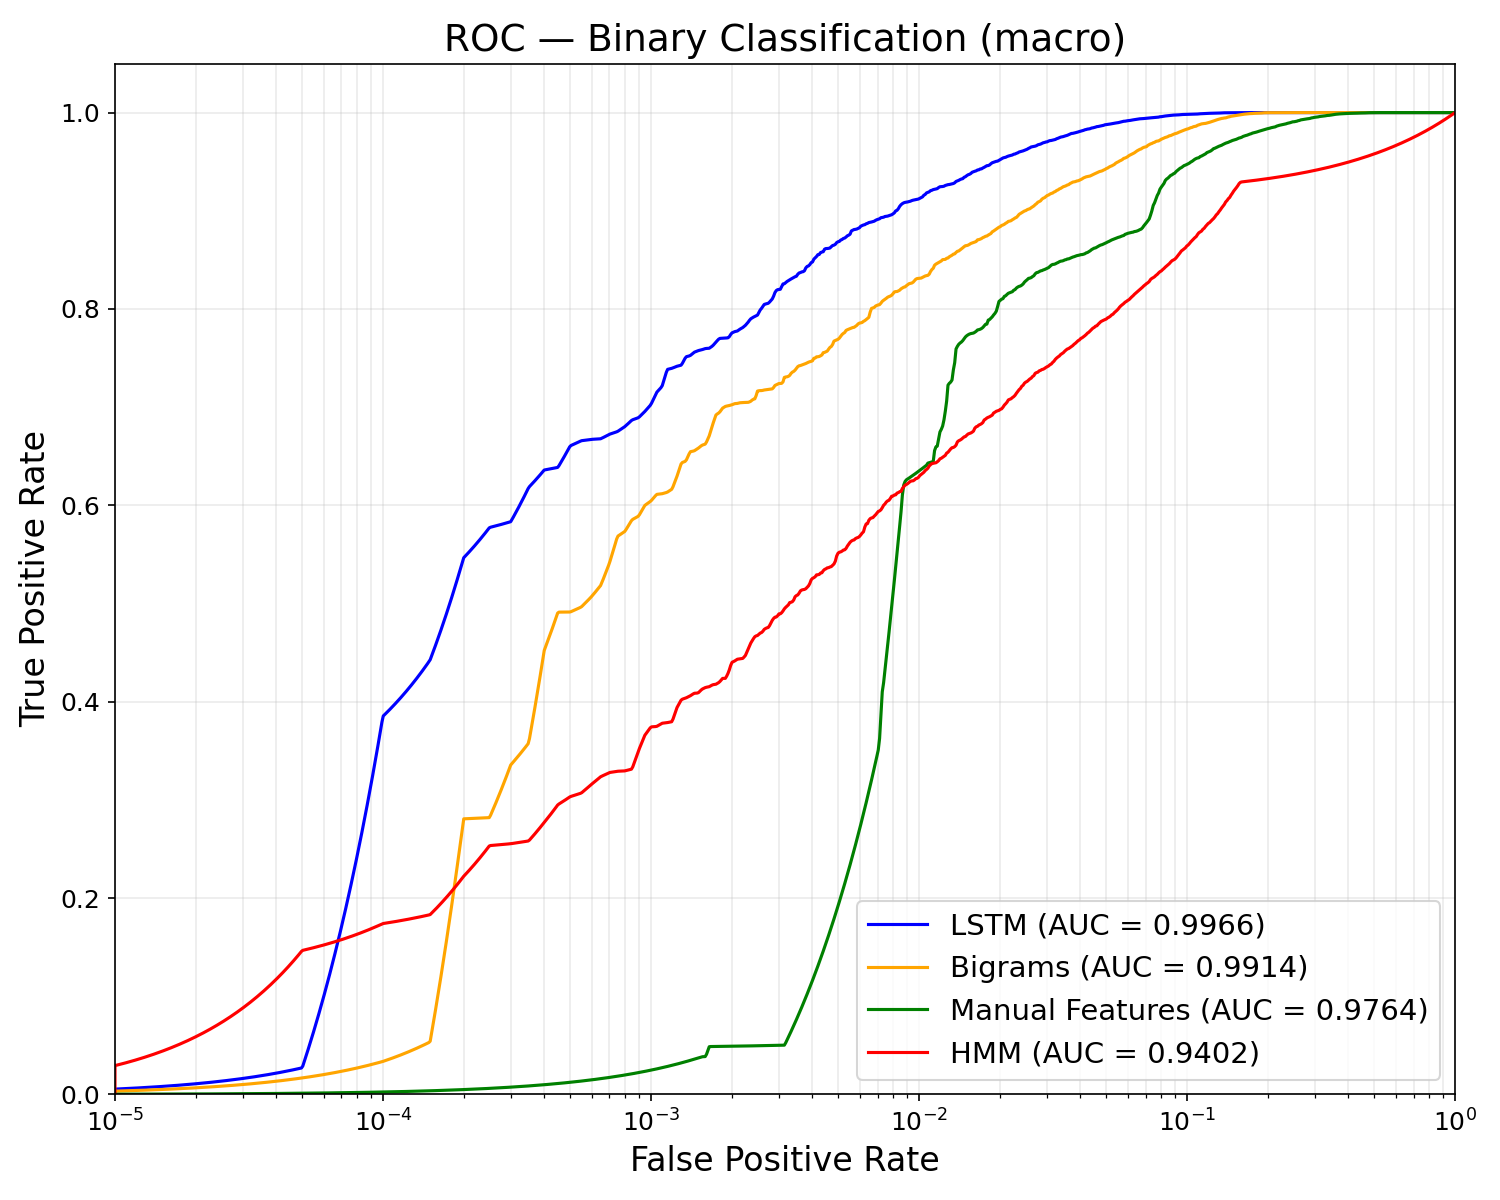

-rw-r--r-- 1 root root      710 Jun 12 00:05 lco_results.pkl
-rw-r--r-- 1 root root 22833874 Jun 12 01:02 multi_results_familias.pkl
-rw-r--r-- 1 root root 10373230 Jun 12 01:30 multi_results_superfamilias.pkl
-rw-r--r-- 1 root root  3543307 Jun 11 23:32 results_binary.pkl
-rw-r--r-- 1 root root   154298 Jun 11 23:32 results_roc.png


In [9]:
from IPython.display import Image, display
import os
if os.path.isfile('results_roc.png'):
    display(Image('results_roc.png'))
!ls -la *.pkl results_roc.png 2>/dev/null

In [10]:
!zip -r resultados_dga.zip *.pkl *.png

  adding: lco_results.pkl (deflated 30%)
  adding: multi_results_familias.pkl (deflated 32%)
  adding: multi_results_superfamilias.pkl (deflated 41%)
  adding: results_binary.pkl (deflated 78%)
  adding: results_roc.png (deflated 7%)
